In [3]:
import pyodbc
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
# Connecting to SQL Server Using pyodbc and Windows Authentication 
conn_str = (
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=DESKTOP-517MHA7;'
    'DATABASE=Agriculture;'
    'Trusted_Connection=yes;'
)

# Connect to SQL Server
conn = pyodbc.connect(conn_str)
print("Connection successful!")

Connection successful!


In [13]:
# Querying Crop Recommendation table and displaying sample records
query = "SELECT * FROM Crop_recommendation" 
df = pd.read_sql(query, conn)
print(df.head())


    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002747  6.502985  202.935532  rice
1  85  58  41    21.770462  80.319641  7.038096  226.655533  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964233  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864029  rice
4  78  42  42    20.130175  81.604874  7.628473  262.717346  rice


C:\Users\ELITE G7\AppData\Local\Temp\ipykernel_28940\2384570142.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [16]:
# Exploratory Data Analysis (EDA) on the Crop Recommendation Dataset
print(f'The first five rows of the dataset are:\n{df.head()}')
print("=" * 80)
print(f'The information about the dataset is:')
print(df.info())
print("=" * 80)
print(f'The shape of the dataset is:\n{df.shape}')
print("=" * 80)
print(f'The columns in the dataset are:\n{df.columns}')
print("=" * 80)
print("Missing values in each column:")
print(df.isnull().sum())
print(f'\nDataset statistical summary:\n{df.describe()}')


The first five rows of the dataset are:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002747  6.502985  202.935532  rice
1  85  58  41    21.770462  80.319641  7.038096  226.655533  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964233  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864029  rice
4  78  42  42    20.130175  81.604874  7.628473  262.717346  rice
The information about the dataset is:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 


In [15]:
# Show unique values in categorical columns
print(f'The unique values in the categorical columns are:')
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"\n Unique values in '{col}': {df[col].unique()}")
print("=" * 80)

The unique values in the categorical columns are:

 Unique values in 'label': ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [19]:
# To check for duplicate in rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


In [20]:
# Set plot style
sns.set(style="whitegrid", palette="Set2")

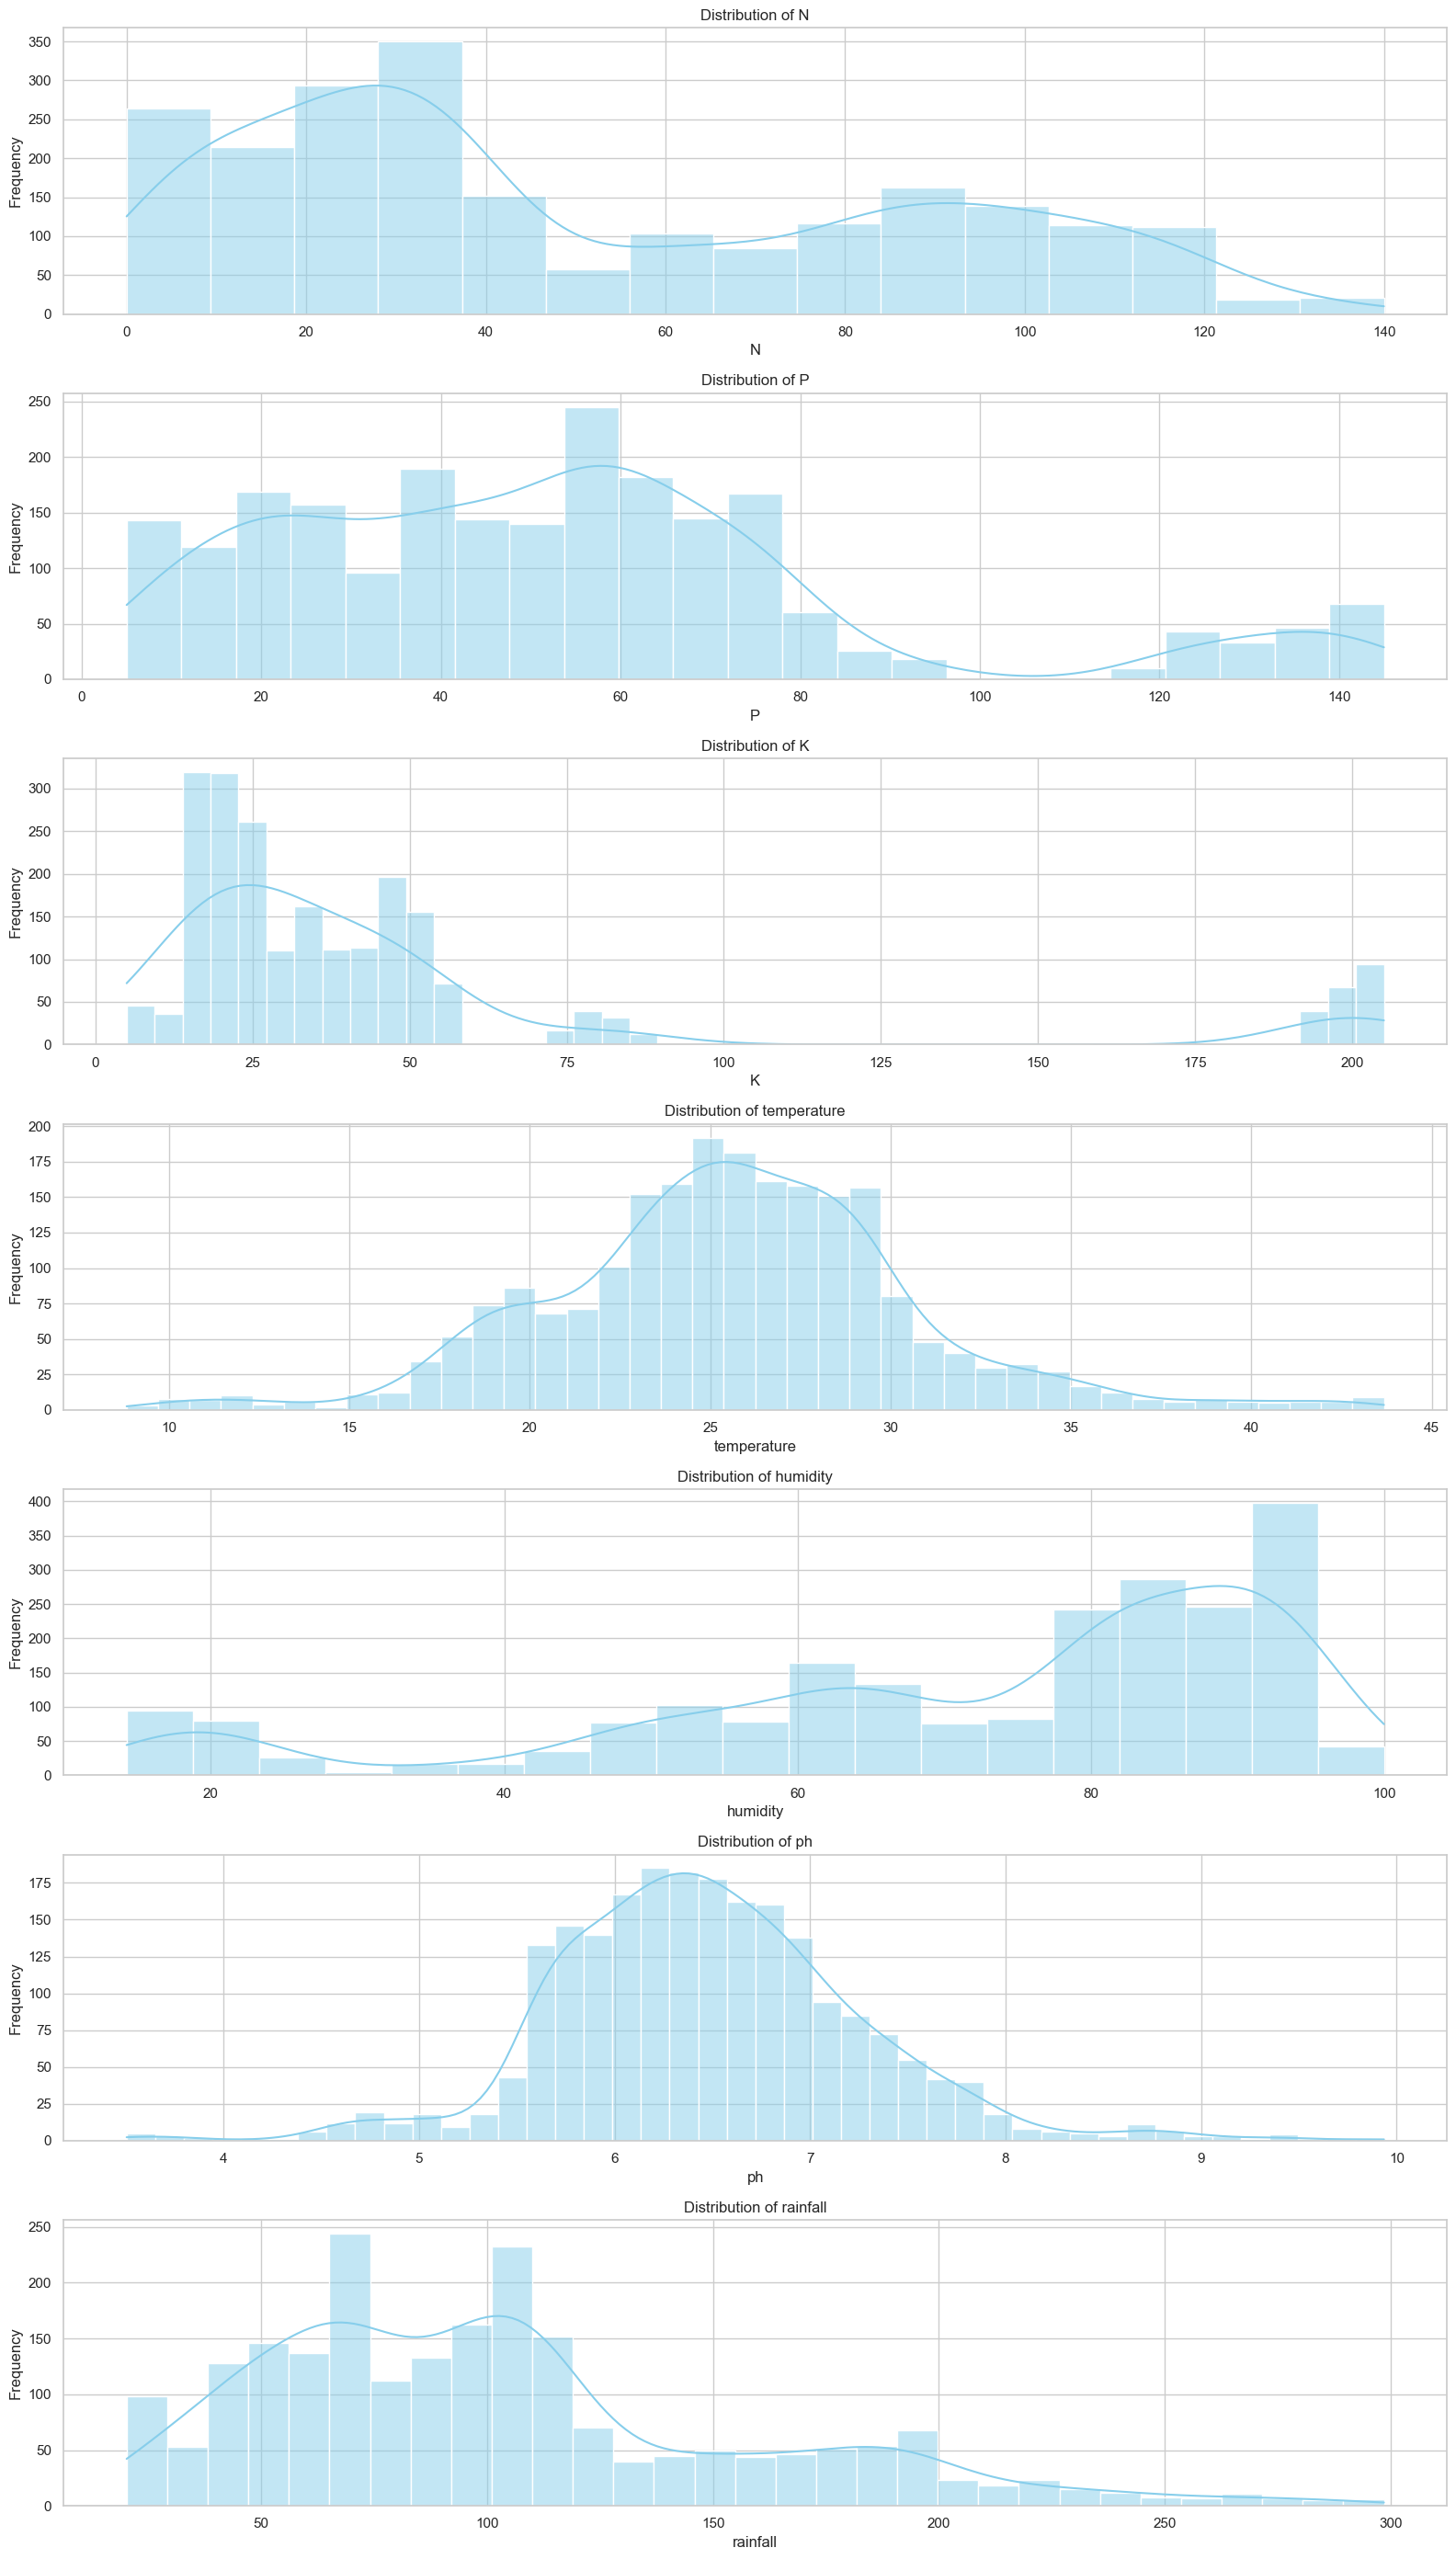

In [ ]:
# univariate analysis on all numerical columns

# Select only numerical columns from the dataset
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set plot size and layout
plt.figure(figsize=(16, 4 * len(numerical_cols)))

# Loop through each numerical column and plot
for idx, col in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols), 1, idx)
    sns.histplot(df[col], kde=True, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


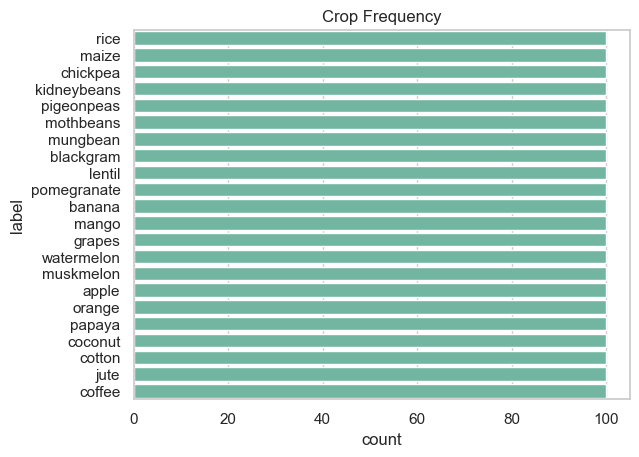

In [23]:
# univariate analysis for the categorical columns

# Count of crops
sns.countplot(y='label', data=df, order=df['label'].value_counts().index)
plt.title('Crop Frequency')
plt.show()


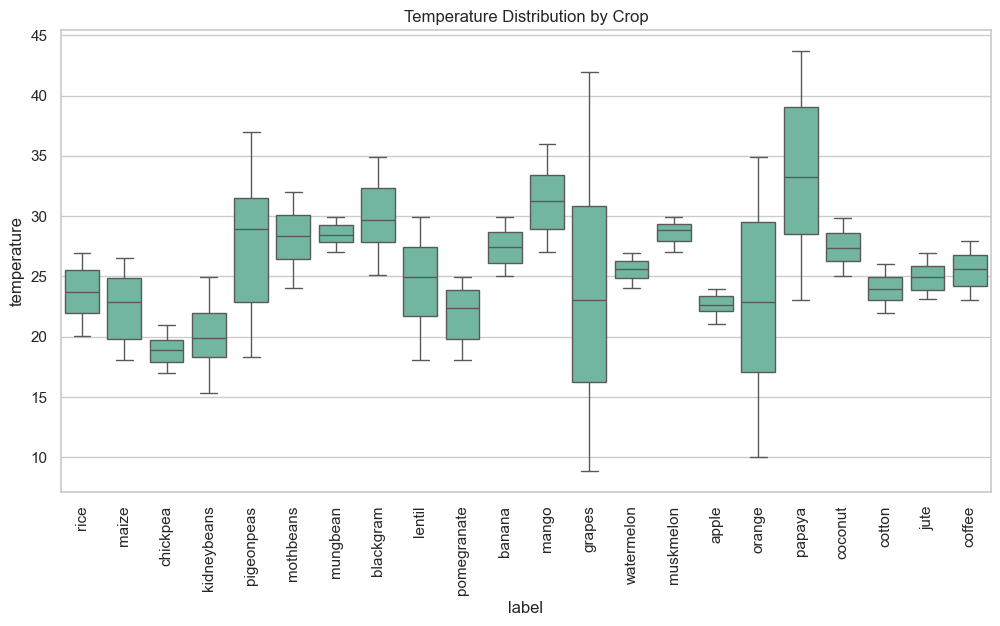

In [24]:
# Boxplot of temperature by crop
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='temperature', data=df)
plt.xticks(rotation=90)
plt.title('Temperature Distribution by Crop')
plt.show()


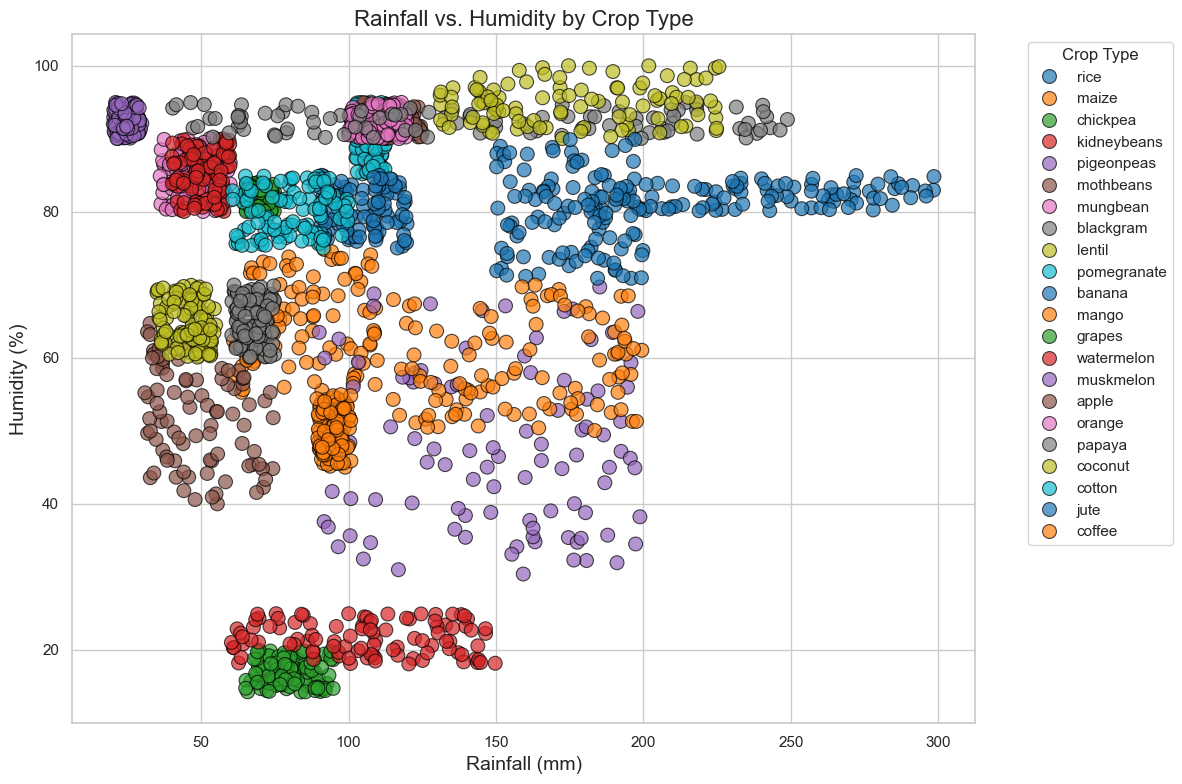

In [31]:

# Set plot style for better visuals
sns.set(style="whitegrid")

plt.figure(figsize=(12, 8))

# Create scatter plot
scatter = sns.scatterplot(
    x='rainfall',          # X-axis: Amount of rainfall (mm)
    y='humidity',          # Y-axis: Humidity percentage (%)
    hue='label',           # Different crops represented by colors
    palette='tab10',       # Color palette for distinction
    data=df,
    s=100,                 # Size of points
    alpha=0.7,             # Transparency to help with overlapping points
    edgecolor='black'      # Outline around points for clarity
)

# Title and axis labels
plt.title('Rainfall vs. Humidity by Crop Type', fontsize=16)
plt.xlabel('Rainfall (mm)', fontsize=14)
plt.ylabel('Humidity (%)', fontsize=14)

# Move the legend outside the plot to the right
plt.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add grid for easier value estimation
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

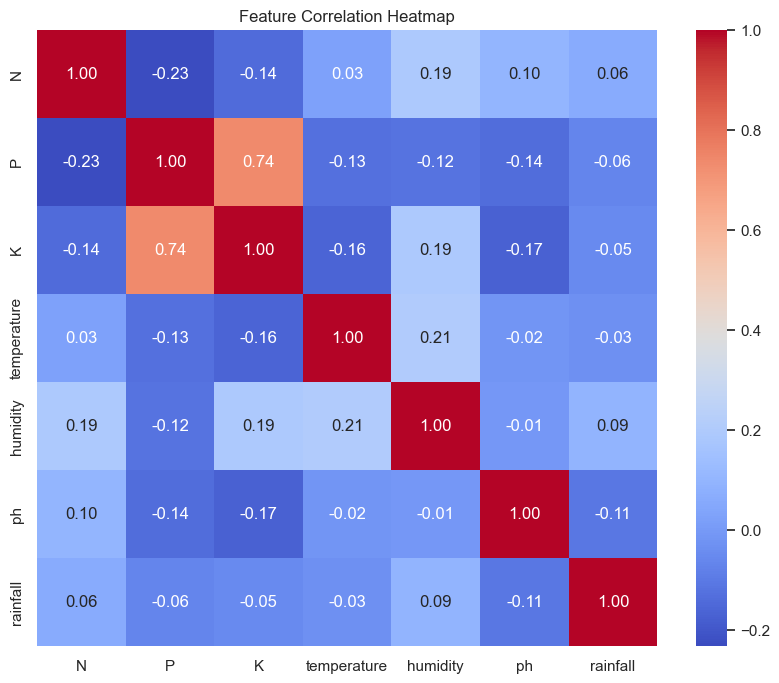

In [26]:
# Exclude categorical column
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()


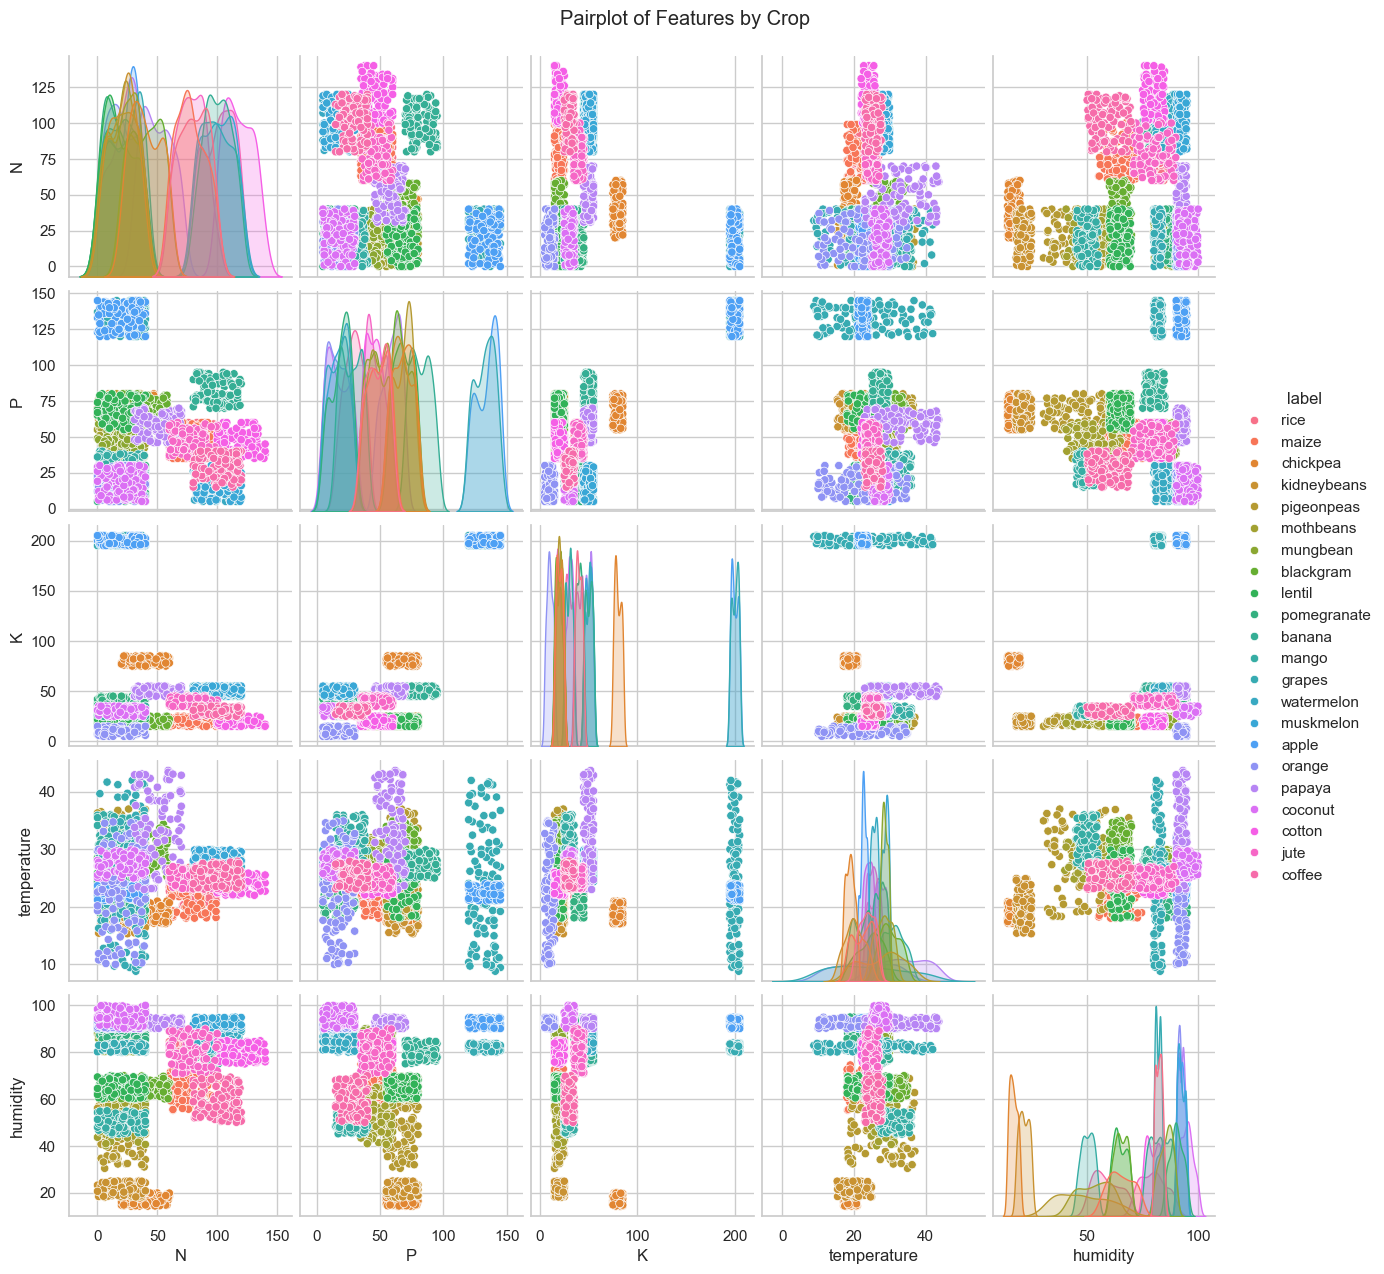

In [27]:
# Pairwise relationships colored by crop label
sns.pairplot(df, hue='label', vars=['N', 'P', 'K', 'temperature', 'humidity'])
plt.suptitle('Pairplot of Features by Crop', y=1.02)
plt.show()
